# Imports

In [1]:
import sys
import os
from pathlib import Path

In [2]:
sys.path.append(os.path.join(os.getcwd(),"..",".."))
sys.path.append(os.path.join(os.getcwd(),"..","..",".."))

In [3]:
import numpy as np
import pandas as pd

In [4]:
import pyfolio as pf
from pyfolio.plotting import plot_rolling_returns,plot_rolling_sharpe
from pyfolio.timeseries import forecast_cone_bootstrap

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import warnings
warnings.filterwarnings("ignore")

In [7]:
from backtester import BackTester

In [8]:
data_store=Path(os.getcwd()).parent.parent.parent/"Prepared_Data_Store"

# Loading Benchmark Data

In [9]:
benchmark_data=pd.read_csv(
    os.path.join(data_store,"sp500_data.csv"),
    parse_dates=["date"],
    index_col=["date"]
)

In [10]:
benchmark_data=benchmark_data.sp500_returns.sort_index().tz_localize("UTC")

# BackTesting

## Trading Strategy-I

### Here we will long the stocks with higher factor values and short the stocks with lower factor values predicted by Ridge Model-15 with reg_aplha=1000

In [11]:
trading_strategy={
    "strategy":"returns_based",
    "values":{}
}

In [12]:
backtester=BackTester(
    n_longs=20,
    n_shorts=20,
    min_positions=10,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.01,
    predictions_file=os.path.join(data_store,"ridge_factors.csv"),
    predictions_column_name="Ridge15_factor",
    trading_strategy=trading_strategy
)

In [13]:
results=backtester.run_backtesting()

[INFO]: Model predictions loaded...
[INFO]: Missing Date Values added in Model Predictions...
[INFO]: Model Data Loader created...
[INFO]: Backtesting started for trading strategy-I...
[INFO]: Backtesting completed...


### Performance Analysis using Pyfolio

In [14]:
LIVE_DATE="2016-02-24"

#### Extracting Information from Zipline Results

In [15]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe

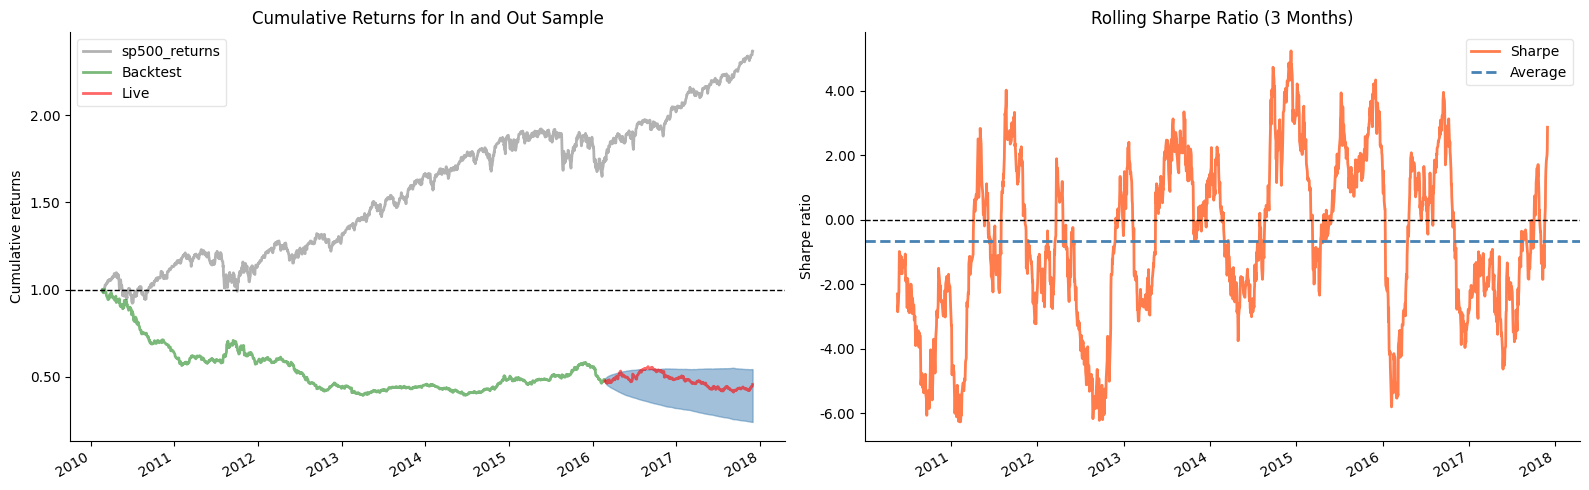

In [16]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    volatility_match=False,
    legend_loc="best",
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns for In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 Months)")

sns.despine()
fig.tight_layout()

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,60.68,2010-03-04,2013-04-04,NaT,NaN
1,1.82,2010-02-22,2010-02-26,2010-03-04,9
2,NaN,NaT,NaT,NaT,NaN
3,NaN,NaT,NaT,NaT,NaN
4,NaN,NaT,NaT,NaT,NaN


Stress Events,mean,min,max
US downgrade/European Debt Crisis,0.49%,-3.94%,6.76%
Fukushima,0.02%,-1.28%,1.02%
EZB IR Event,-0.25%,-2.19%,1.18%
Flash Crash,-0.62%,-3.17%,1.44%
Apr14,-0.20%,-2.05%,1.43%
Oct14,0.04%,-1.76%,2.24%
Fall2015,0.15%,-1.80%,3.57%
Recovery,-0.11%,-3.94%,6.76%
New Normal,0.01%,-6.10%,5.60%


Top 10 long positions of all time,max
sid,
APA,39.04%
HSY,34.47%
NEM,34.04%
DGX,33.95%
RF,33.84%
MOS,33.70%
NVDA,33.68%
DECK,30.86%
COP,30.80%


Top 10 short positions of all time,max
sid,
MDLZ,-40.74%
DGX,-38.95%
NEM,-38.48%
NVDA,-38.00%
RF,-37.88%
COP,-36.05%
APA,-35.88%
AEE,-34.21%
WTW,-31.95%


Top 10 positions of all time,max
sid,
MDLZ,40.74%
APA,39.04%
DGX,38.95%
NEM,38.48%
NVDA,38.00%
RF,37.88%
COP,36.05%
HSY,34.47%
AEE,34.21%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$-552835.35,$-922748.35,$369913.00
Gross profit,$13663579.55,$6670190.54,$6993389.00
Gross loss,$-14216414.90,$-7592938.89,$-6623476.01
Profit factor,$0.96,$0.88,$1.06
Avg. trade net profit,$-7.25,$-24.57,$9.56
Avg. winning trade,$363.99,$375.28,$353.84
Avg. losing trade,$-369.45,$-386.08,$-352.07
Ratio Avg. Win:Avg. Loss,$0.99,$0.97,$1.01
Largest winning trade,$16684.12,$16684.12,$15578.38
Largest losing trade,$-24674.76,$-24674.76,$-18392.00


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 13:57:16.646724020,1 days 17:01:03.260150696,1 days 10:58:53.197167446
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,269 days 21:00:00,269 days 21:00:00,5 days 03:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,-0.00%,-0.00%,0.00%
Avg returns winning,0.07%,0.07%,0.07%
Avg returns losing,-0.07%,-0.07%,-0.06%
Median returns all round_trips,-0.00%,-0.00%,0.00%
Median returns winning,0.04%,0.04%,0.04%
Median returns losing,-0.04%,-0.04%,-0.04%
Largest winning trade,3.88%,3.88%,3.40%
Largest losing trade,-5.65%,-5.65%,-2.56%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HD,HIG,HOLX,HON,HPQ,HRL,HSIC,HST,HSY,HUM,IBM,ICE,IDXX,IEX,IFF,INCY,INTU,IP,IPG,IR,IRM,ISRG,IT,ITW,IVZ,JBHT,JBL,JCI,JKHY,JNJ,JPM,K,KEY,KIM,KLAC,KMB,KMX,KO,KR,L,LDOS,LEN,LH,LII,LKQ,LLY,LMT,LNT,LRCX,LUV,LVS,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,MGM,MHK,MKC,MKTX,MLM,MMC,MNST,MO,MOH,MOS,MPWR,MRK,MS,MSCI,MSFT,MSI,MTB,MTD,MU,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,O,ODFL,OKE,OMC,ORCL,ORLY,OXY,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PWR,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,SBAC,SBUX,SCHW,SHW,SJM,SLB,SMCI,SNA,SNPS,SO,SPG,SRE,STE,STLD,STT,STX,STZ,SWK,SWKS,SYK,SYY,T,TAP,TDG,TDY,TECH,TEL,TER,TGT,TJX,TMO,TMUS,TRMB,TROW,TSCO,TSN,TTWO,TXN,TXT,TYL,UAL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VLO,VMC,VRSK,VRSN,VRTX,VTR,VZ,WAB,WAT,WBA,WDC,WEC,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Avg returns all round_trips,-0.00%,-0.01%,-0.00%,0.01%,-0.00%,0.00%,-0.00%,0.00%,0.00%,-0.01%,-0.01%,-0.00%,-0.00%,0.00%,0.01%,-0.01%,0.00%,-0.00%,-0.01%,0.00%,-0.00%,-0.00%,0.02%,-0.01%,0.00%,0.00%,-0.00%,0.01%,0.01%,-0.01%,-0.00%,0.01%,0.01%,0.00%,-0.00%,-0.01%,0.00%,0.02%,0.00%,0.01%,0.00%,0.01%,0.01%,0.00%,0.01%,-0.00%,0.02%,0.00%,-0.01%,-0.00%,-0.01%,-0.00%,-0.00%,0.00%,-0.01%,0.01%,-0.00%,0.00%,-0.01%,-0.01%,0.01%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.01%,-0.01%,0.02%,-0.00%,-0.00%,-0.01%,0.00%,-0.01%,0.01%,0.01%,0.00%,0.00%,0.00%,0.01%,-0.00%,-0.01%,-0.01%,0.01%,-0.01%,-0.00%,0.01%,0.00%,-0.01%,0.01%,-0.00%,0.00%,0.01%,-0.02%,-0.01%,0.00%,0.00%,0.01%,0.01%,0.01%,0.00%,0.01%,-0.00%,-0.00%,0.02%,-0.01%,0.00%,0.01%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,0.01%,0.01%,0.00%,-0.02%,0.01%,0.00%,-0.01%,-0.00%,-0.01%,-0.01%,-0.01%,0.01%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.01%,-0.00%,0.00%,0.01%,0.00%,-0.00%,0.01%,0.01%,0.00%,-0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,-0.01%,0.00%,0.01%,0.00%,0.02%,-0.01%,0.00%,0.00%,-0.02%,0.01%,0.00%,-0.00%,-0.02%,-0.00%,-0.00%,-0.01%,0.00%,0.00%,0.01%,0.00%,0.00%,-0.02%,-0.01%,-0.01%,-0.01%,-0.00%,-0.01%,-0.04%,-0.01%,0.00%,0.01%,-0.01%,-0.02%,0.01%,-0.00%,-0.01%,-0.01%,0.01%,0.00%,-0.00%,-0.00%,-0.02%,0.01%,0.01%,-0.01%,-0.00%,-0.01%,0.00%,-0.01%,-0.01%,0.00%,0.01%,-0.01%,-0.01%,-0.01%,0.00%,0.00%,0.00%,-0.00%,-0.01%,0.01%,0.01%,0.00%,0.01%,-0.01%,-0.01%,-0.01%,-0.01%,-0.01%,-0.01%,0.00%,-0.01%,0.00%,-0.00%,-0.00%,0.00%,0.01%,-0.00%,0.00%,0.00%,0.01%,-0.00%,0.01%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.02%,0.01%,-0.03%,-0.01%,0.00%,0.00%,0.00%,0.01%,-0.00%,-0.00%,-0.01%,-0.02%,-0.02%,-0.00%,0.00%,-0.01%,-0.02%,-0.00%,0.01%,-0.01%,0.01%,-0.01%,0.00%,-0.00%,0.00%,-0.01%,-0.00%,0.00%,0.00%,-0.00%,0.00%,-0.01%,-0.00%,-0.01%,0.01%,0.00%,-0.00%,-0.00%,0.00%,0.00%,0.00%,-0.00%,-0.01%,-0.02%,-0.00%,-0.01%,-0.01%,0.00%,0.01%,-0.01%,0.00%,-0.00%,-0.04%,-0.00%,0.01%,-0.04%,0.01%,0.00%,0.02%,0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.01%,-0.01%,0.00%,-0.02%,0.01%,0.02%,0.00%,-0.00%,-0.01%,0.00%,-0.00%,0.01%,0.01%,-0.03%,-0.01%,0.02%,-0.00%,-0.00%,0.01%,-0.00%,0.01%,0.01%,-0.00%,0.01%,-0.00%,0.01%,0.00%,-0.01%,-0.02%,0.01%,-0.02%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,0.01%,0.00%,-0.01%,0.01%,-0.01%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.01%,-0.01%,0.01%,0.01%,-0.03%,-0.01%,-0.00%,0.00%,-0.01%,-0.00%,-0.01%,-0.01%,0.01%,-0.01%,-0.03%,-0.01%,0.01%,0.01%,-0.00%,0.02%,0.00%,0.01%,-0.00%,0.00%,-0.01%,0.01%,-0.02

Profitability (PnL / PnL total) per name,
symbol,
MU,9.36%
RMD,9.27%
NVDA,7.59%
VRTX,7.43%
RF,7.26%
IPG,6.98%
SMCI,5.63%
TMUS,5.37%
STZ,5.17%


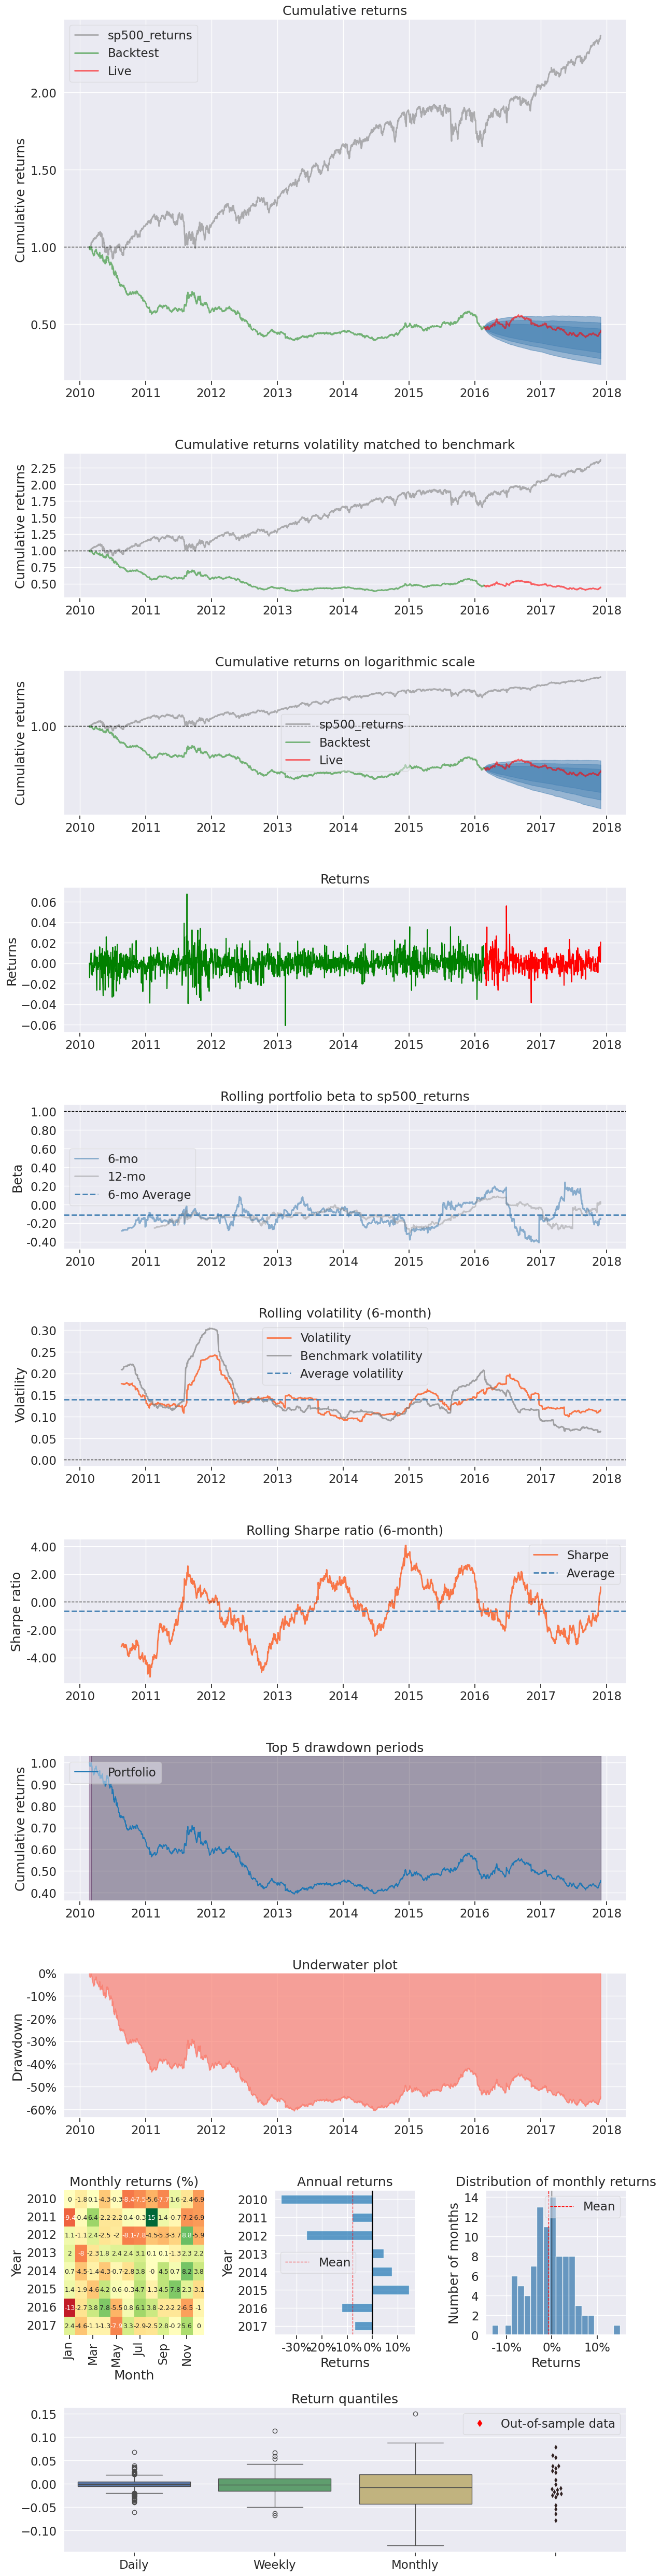

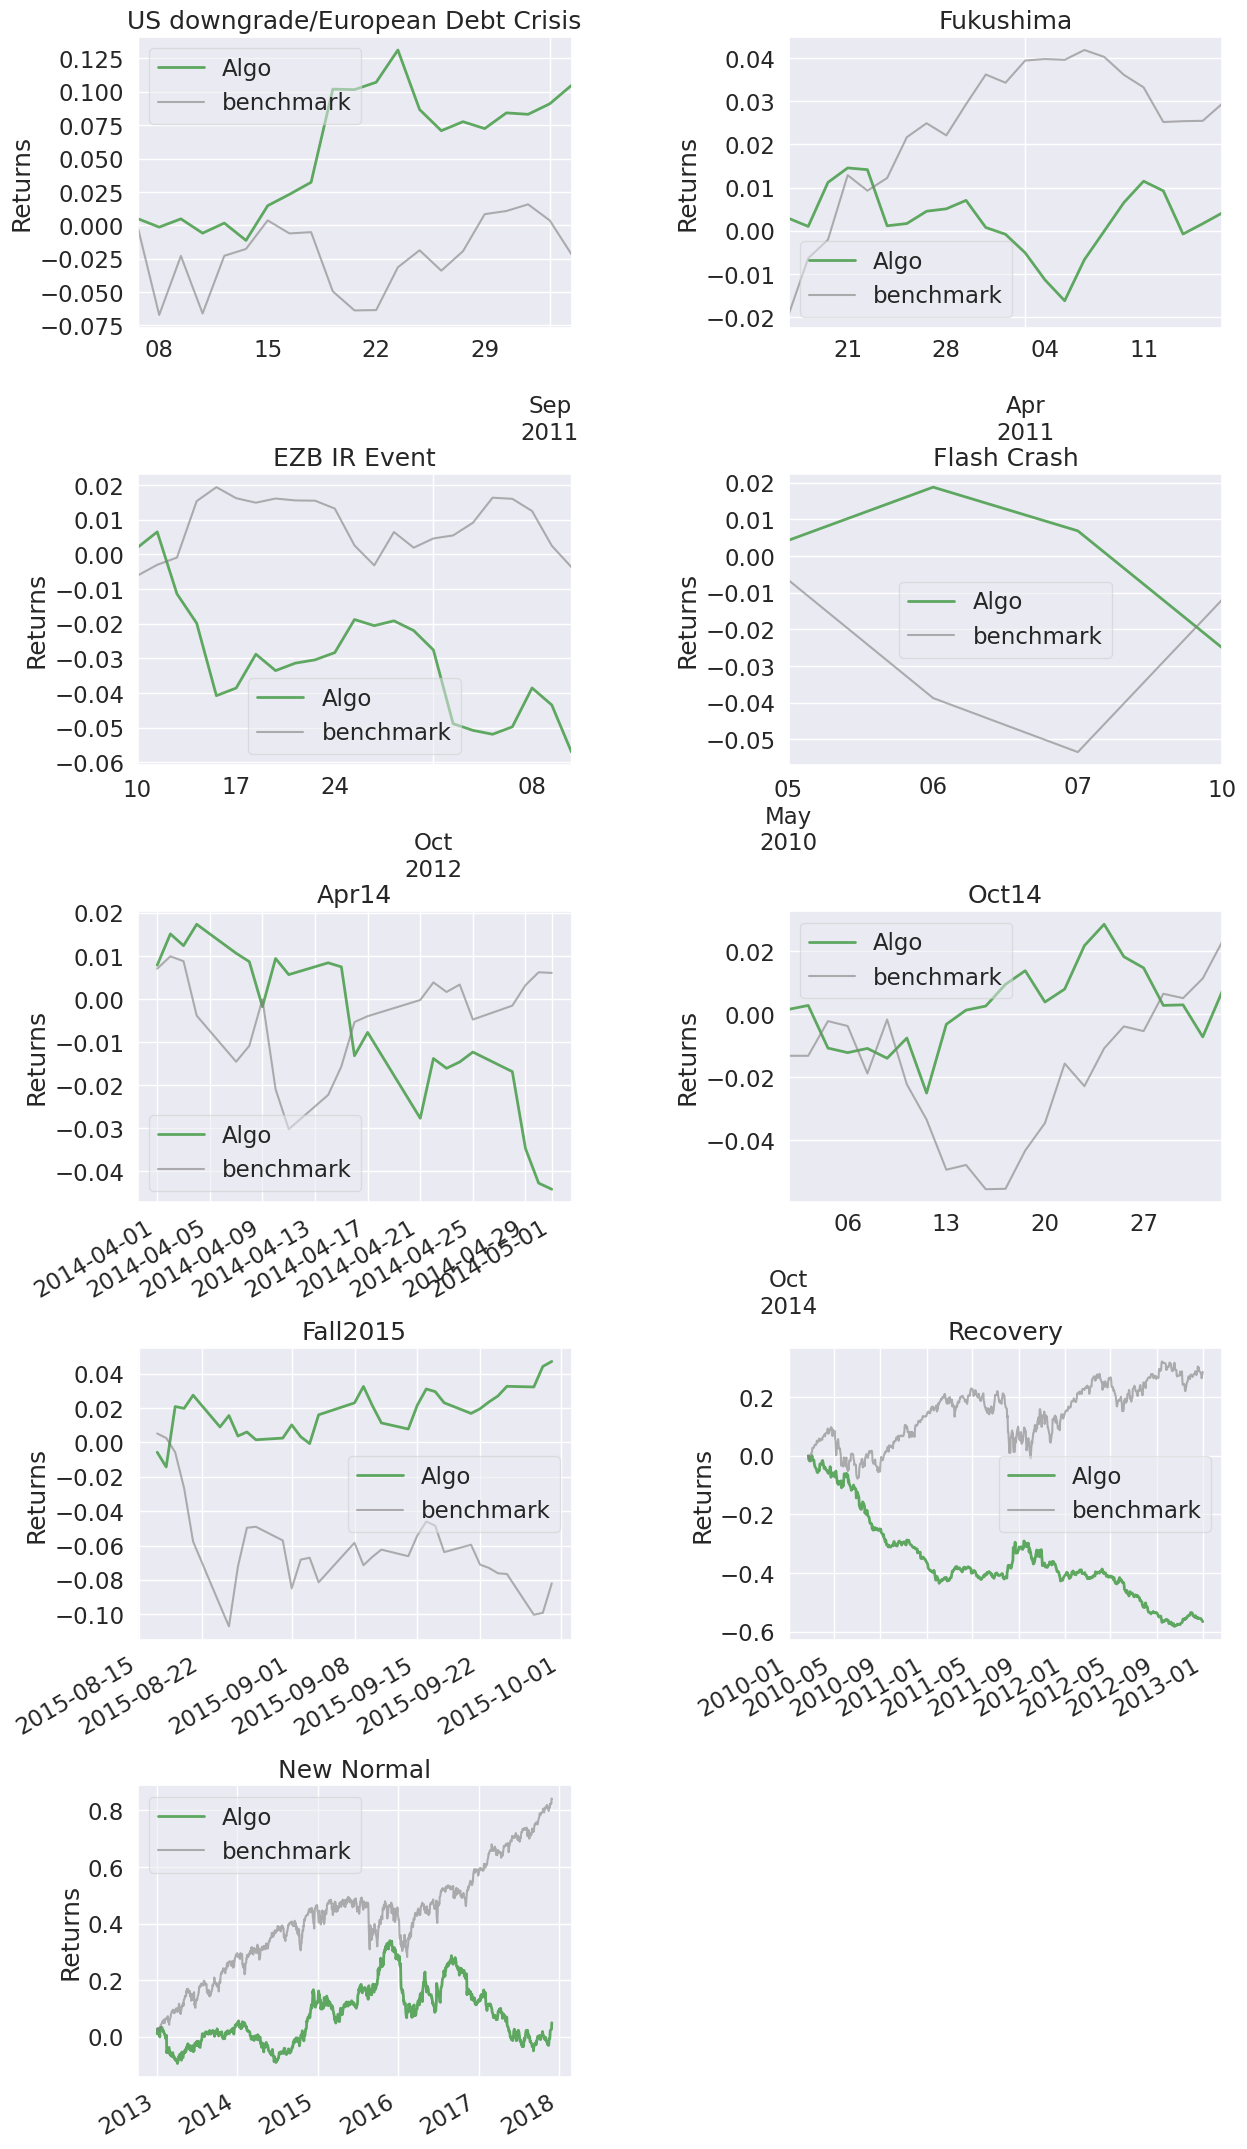

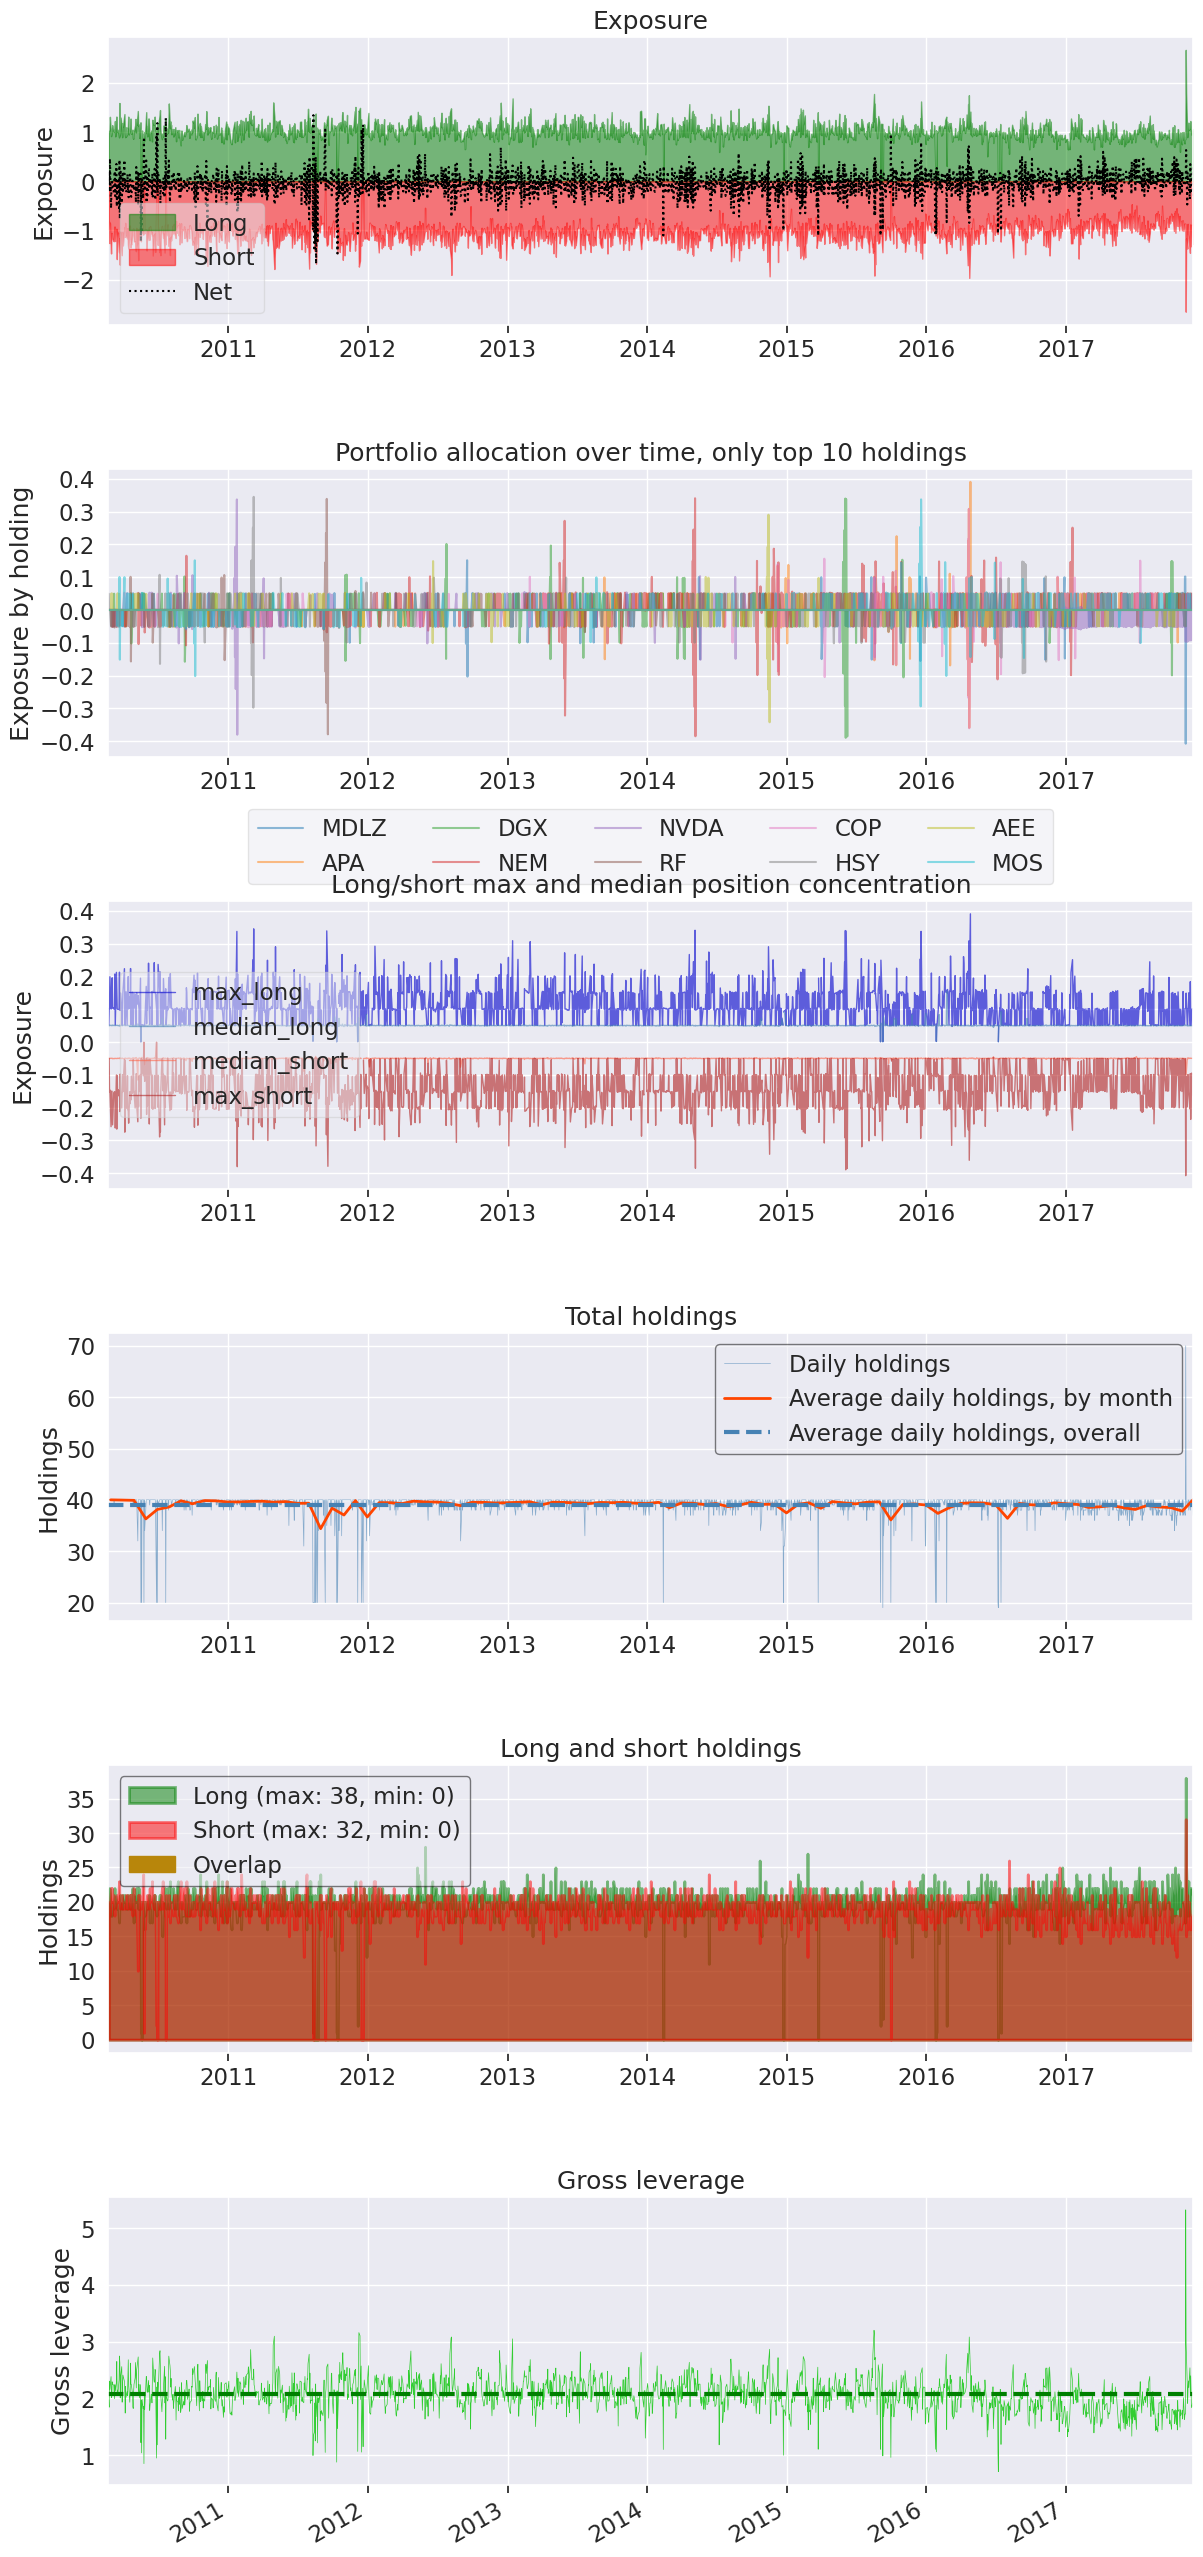

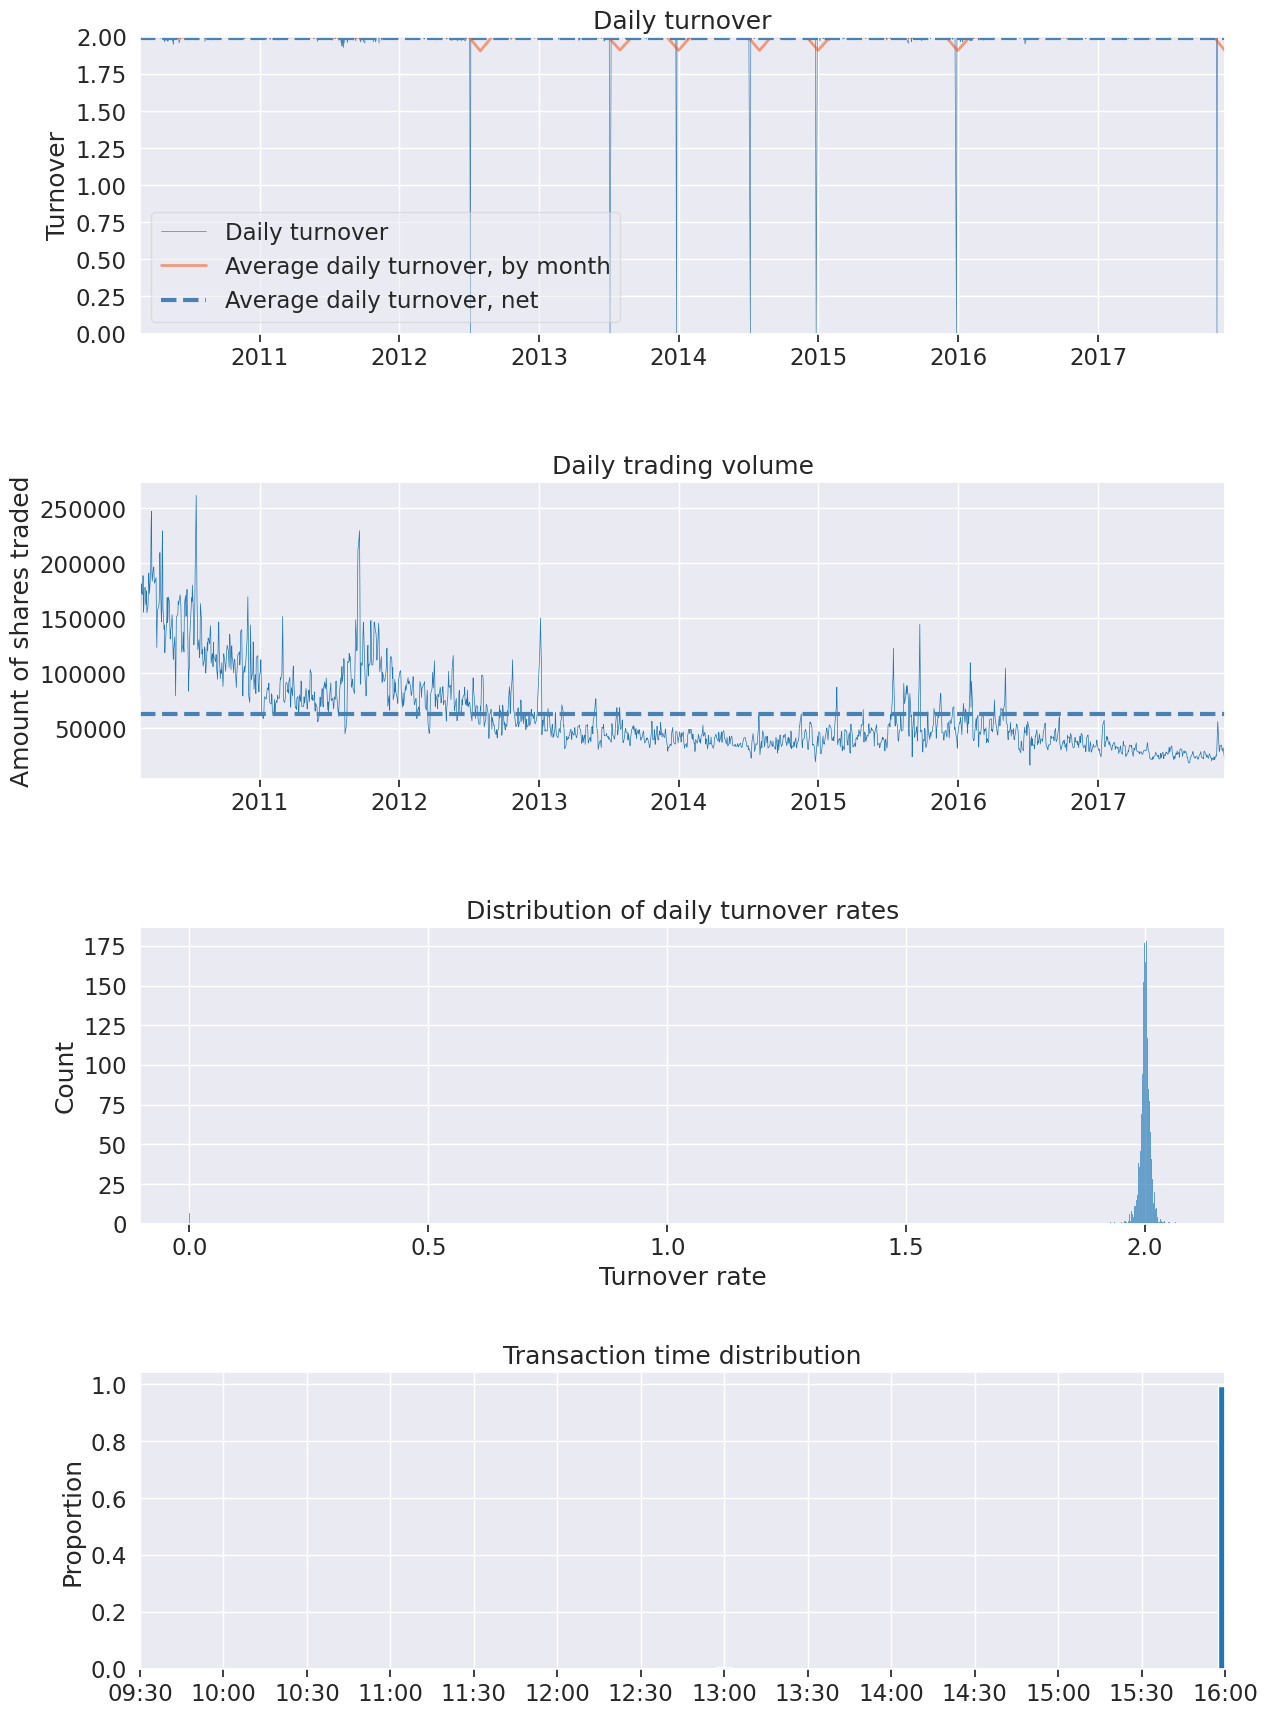

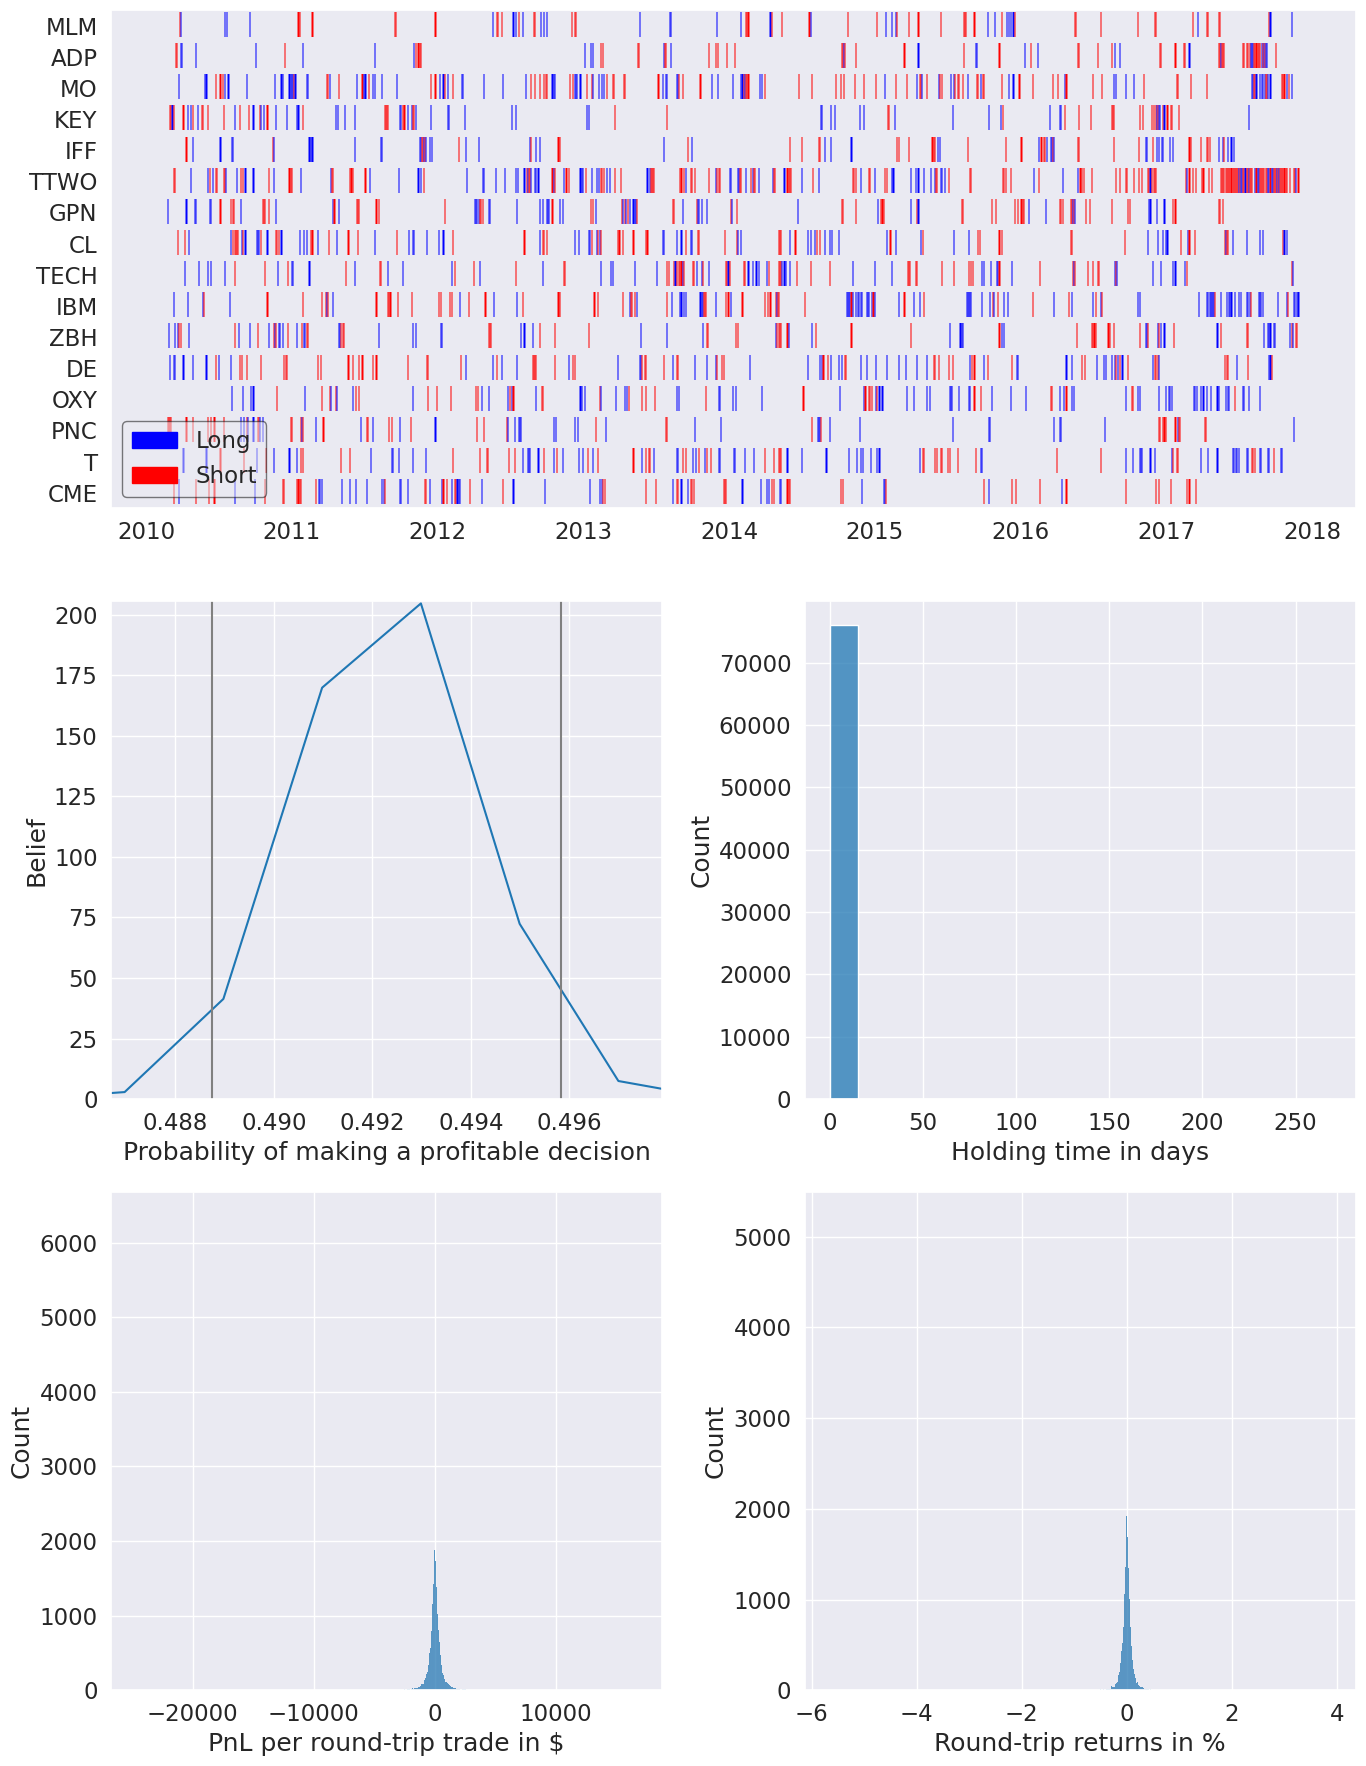

In [17]:
pf.create_full_tear_sheet(
    returns,
    transactions=transactions,
    positions=positions,
    live_start_date=LIVE_DATE,
    benchmark_rets=benchmark_data,
    round_trips=True
)

## Trading Strategy-II

### As seen in signal evaluations of the factors of the Ridge Model-15 (alpha=1000), we will long factors in quantile-3 and short factors in quantile-5

In [18]:
trading_strategy={
    "strategy":"quantile_based",
    "values":{
        "quantile_long":3,
        "quantile_short":5
    }
}

In [19]:
backtester=BackTester(
    n_longs=20,
    n_shorts=20,
    min_positions=5,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.00,
    predictions_file=os.path.join(data_store,"ridge_factors.csv"),
    predictions_column_name="Ridge15_factor",
    trading_strategy=trading_strategy
)

In [20]:
results=backtester.run_backtesting()

[INFO]: Model predictions loaded...
[INFO]: Missing Date Values added in Model Predictions...
[INFO]: Model Data Loader created...
[INFO]: Backtesting started for trading strategy-II...
[INFO]: Backtesting completed...


### Performance Analysis using Pyfolio

#### Extracting Information from Zipline Results

In [21]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe

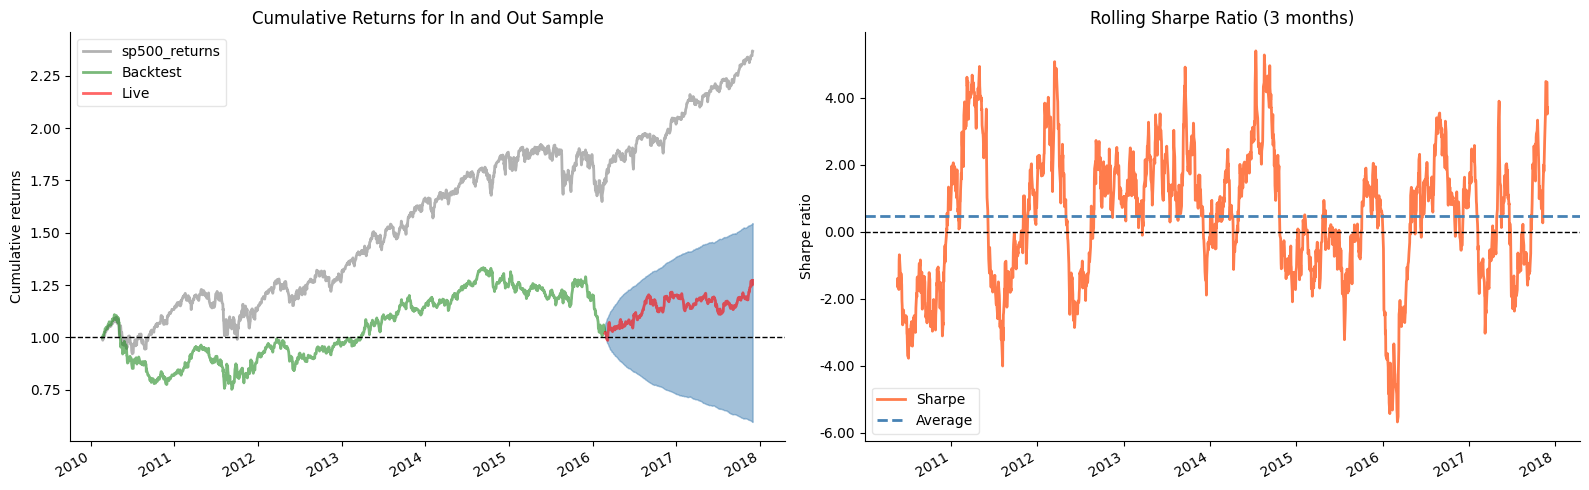

In [22]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    legend_loc="best",
    volatility_match=False,
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns for In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 months)")

sns.despine()
fig.tight_layout()

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,32.17,2010-04-15,2011-09-09,2013-08-01,861
1,26.07,2014-09-11,2016-03-07,NaT,NaN
2,7.79,2013-10-23,2013-12-12,2014-05-02,138
3,3.78,2013-09-19,2013-10-08,2013-10-16,20
4,3.05,2013-08-01,2013-08-19,2013-08-27,19


Stress Events,mean,min,max
US downgrade/European Debt Crisis,-0.07%,-6.59%,6.23%
Fukushima,0.20%,-1.30%,1.52%
EZB IR Event,0.08%,-1.05%,1.61%
Flash Crash,-1.73%,-2.73%,0.34%
Apr14,0.16%,-2.15%,0.91%
Oct14,-0.25%,-1.97%,1.86%
Fall2015,-0.07%,-4.04%,2.99%
Recovery,0.00%,-6.59%,6.23%
New Normal,0.02%,-4.04%,3.33%


Top 10 long positions of all time,max
sid,
AES,28.85%
PWR,24.35%
NOC,23.52%
CAG,22.21%
LLY,22.09%
BDX,20.09%
KLAC,20.09%
AMT,19.98%
TRMB,19.94%


Top 10 short positions of all time,max
sid,
AES,-24.39%
BLDR,-22.37%
DVN,-20.52%
ADP,-20.39%
HST,-20.36%
BG,-20.30%
WBA,-20.18%
ULTA,-20.13%
HPQ,-20.02%


Top 10 positions of all time,max
sid,
AES,28.85%
PWR,24.35%
NOC,23.52%
BLDR,22.37%
CAG,22.21%
LLY,22.09%
DVN,20.52%
ADP,20.39%
HST,20.36%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$151187.53,$-551097.85,$702285.38
Gross profit,$14979928.28,$4718561.18,$10261367.09
Gross loss,$-14828740.74,$-5269659.03,$-9559081.71
Profit factor,$1.01,$0.90,$1.07
Avg. trade net profit,$3.18,$-37.05,$21.48
Avg. winning trade,$625.36,$670.82,$606.46
Avg. losing trade,$-638.76,$-682.69,$-616.87
Ratio Avg. Win:Avg. Loss,$0.98,$0.98,$0.98
Largest winning trade,$30662.10,$30662.10,$19851.73
Largest losing trade,$-30296.30,$-18469.72,$-30296.30


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 14:37:29.781931333,1 days 23:02:02.476030390,1 days 10:47:56.585867237
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,154 days 23:00:00,154 days 23:00:00,5 days 03:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,0.00%,-0.00%,0.00%
Avg returns winning,0.06%,0.06%,0.06%
Avg returns losing,-0.06%,-0.06%,-0.06%
Median returns all round_trips,0.00%,-0.00%,0.00%
Median returns winning,0.04%,0.04%,0.04%
Median returns losing,-0.04%,-0.04%,-0.04%
Largest winning trade,2.61%,2.61%,1.66%
Largest losing trade,-2.58%,-1.88%,-2.58%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HD,HIG,HOLX,HON,HPQ,HRL,HSIC,HST,HSY,HUM,IBM,ICE,IDXX,IEX,IFF,INCY,INTU,IP,IPG,IR,IRM,ISRG,IT,ITW,IVZ,JBHT,JBL,JCI,JKHY,JNJ,JPM,K,KEY,KIM,KLAC,KMB,KMX,KO,KR,L,LDOS,LEN,LH,LII,LKQ,LLY,LMT,LNT,LRCX,LUV,LVS,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,MGM,MHK,MKC,MKTX,MLM,MMC,MNST,MO,MOH,MOS,MPWR,MRK,MS,MSCI,MSFT,MSI,MTB,MTD,MU,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,O,ODFL,OKE,OMC,ORCL,ORLY,OXY,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PWR,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,SBAC,SBUX,SCHW,SHW,SJM,SLB,SMCI,SNA,SNPS,SO,SPG,SRE,STE,STLD,STT,STX,STZ,SWK,SWKS,SYK,SYY,T,TAP,TDG,TDY,TECH,TEL,TER,TGT,TJX,TMO,TMUS,TRMB,TROW,TSCO,TSN,TTWO,TXN,TXT,TYL,UAL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VLO,VMC,VRSK,VRSN,VRTX,VTR,VZ,WAB,WAT,WBA,WDC,WEC,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Avg returns all round_trips,-0.00%,0.00%,0.01%,-0.00%,0.01%,0.01%,-0.00%,0.00%,0.01%,0.02%,-0.02%,-0.00%,-0.00%,-0.01%,0.01%,-0.01%,-0.00%,-0.01%,-0.01%,0.02%,-0.01%,0.01%,0.00%,-0.00%,-0.00%,0.00%,0.01%,0.01%,-0.01%,-0.00%,-0.01%,0.02%,-0.00%,-0.00%,-0.00%,-0.00%,0.02%,0.02%,-0.00%,0.02%,-0.01%,-0.01%,-0.00%,0.00%,-0.01%,-0.02%,0.01%,-0.00%,0.00%,-0.01%,-0.00%,-0.00%,0.00%,0.00%,0.00%,0.02%,-0.00%,-0.00%,0.01%,-0.00%,0.01%,-0.01%,0.01%,0.00%,0.01%,-0.01%,-0.00%,0.01%,-0.02%,0.01%,0.01%,-0.00%,0.00%,0.01%,0.00%,-0.00%,0.01%,0.00%,-0.01%,0.00%,0.00%,0.00%,0.01%,0.02%,0.01%,-0.01%,0.00%,-0.00%,0.01%,-0.00%,-0.00%,-0.02%,0.00%,0.01%,-0.02%,0.00%,0.00%,0.01%,-0.00%,0.00%,0.01%,0.02%,0.01%,0.00%,-0.01%,-0.00%,0.02%,-0.01%,0.00%,0.01%,0.01%,-0.00%,-0.00%,-0.01%,-0.00%,-0.00%,-0.01%,-0.01%,-0.01%,0.01%,0.00%,0.01%,0.00%,-0.02%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,0.00%,-0.01%,-0.00%,-0.00%,0.00%,-0.01%,0.01%,0.03%,-0.00%,0.00%,0.01%,0.01%,0.01%,0.02%,-0.01%,-0.00%,-0.00%,0.00%,-0.00%,-0.01%,0.00%,-0.00%,0.00%,-0.01%,0.00%,0.00%,-0.01%,-0.00%,0.00%,-0.01%,0.00%,-0.00%,-0.00%,0.01%,-0.01%,0.02%,0.01%,0.01%,-0.01%,0.02%,-0.04%,0.00%,-0.00%,-0.02%,0.01%,0.00%,-0.01%,-0.01%,0.00%,0.00%,0.01%,0.01%,0.00%,0.00%,-0.00%,-0.00%,0.01%,0.00%,0.00%,0.00%,0.00%,-0.00%,-0.01%,0.00%,0.01%,0.00%,0.01%,0.01%,-0.01%,-0.01%,-0.01%,0.00%,-0.00%,-0.01%,0.01%,0.00%,-0.01%,0.00%,0.00%,0.01%,0.01%,-0.00%,0.00%,0.01%,-0.00%,-0.01%,-0.00%,-0.00%,-0.01%,0.01%,-0.01%,0.02%,0.01%,0.00%,-0.01%,-0.00%,0.00%,-0.00%,0.00%,0.00%,0.01%,0.00%,-0.00%,0.01%,-0.01%,-0.00%,0.01%,0.01%,-0.00%,-0.00%,0.00%,0.03%,0.00%,0.01%,-0.02%,0.01%,-0.01%,-0.00%,-0.01%,-0.01%,0.00%,0.01%,-0.01%,-0.01%,-0.01%,0.00%,0.00%,0.00%,0.00%,-0.02%,0.01%,-0.01%,0.01%,0.00%,0.00%,0.00%,0.00%,0.01%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,0.01%,0.01%,-0.01%,-0.00%,-0.00%,-0.01%,-0.00%,-0.00%,0.01%,-0.01%,0.01%,0.00%,-0.00%,0.00%,0.00%,-0.02%,-0.01%,0.00%,-0.01%,-0.00%,0.01%,0.00%,-0.00%,-0.00%,0.01%,0.01%,0.01%,0.01%,-0.00%,-0.00%,-0.00%,-0.02%,-0.00%,-0.00%,0.00%,0.00%,0.00%,-0.00%,0.01%,-0.02%,0.01%,0.00%,0.01%,0.00%,0.00%,0.01%,0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.01%,0.01%,-0.03%,-0.00%,0.00%,0.01%,0.02%,0.01%,0.01%,0.02%,-0.01%,-0.01%,0.01%,0.01%,-0.00%,0.00%,-0.01%,0.02%,0.01%,0.01%,0.00%,-0.01%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.01%,-0.00%,-0.00%,0.02%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.01%,-0.00%,0.00%,0.01%,0.01%,0.01%,0.01%,0.00%,-0.00%,0.00%,0.00%
Avg returns winning,0.

Profitability (PnL / PnL total) per name,
symbol,
TTWO,23.10%
NDSN,22.95%
BBY,22.82%
FICO,22.44%
MGM,22.07%
DXCM,21.92%
CSX,20.29%
CF,17.62%
CPB,16.45%


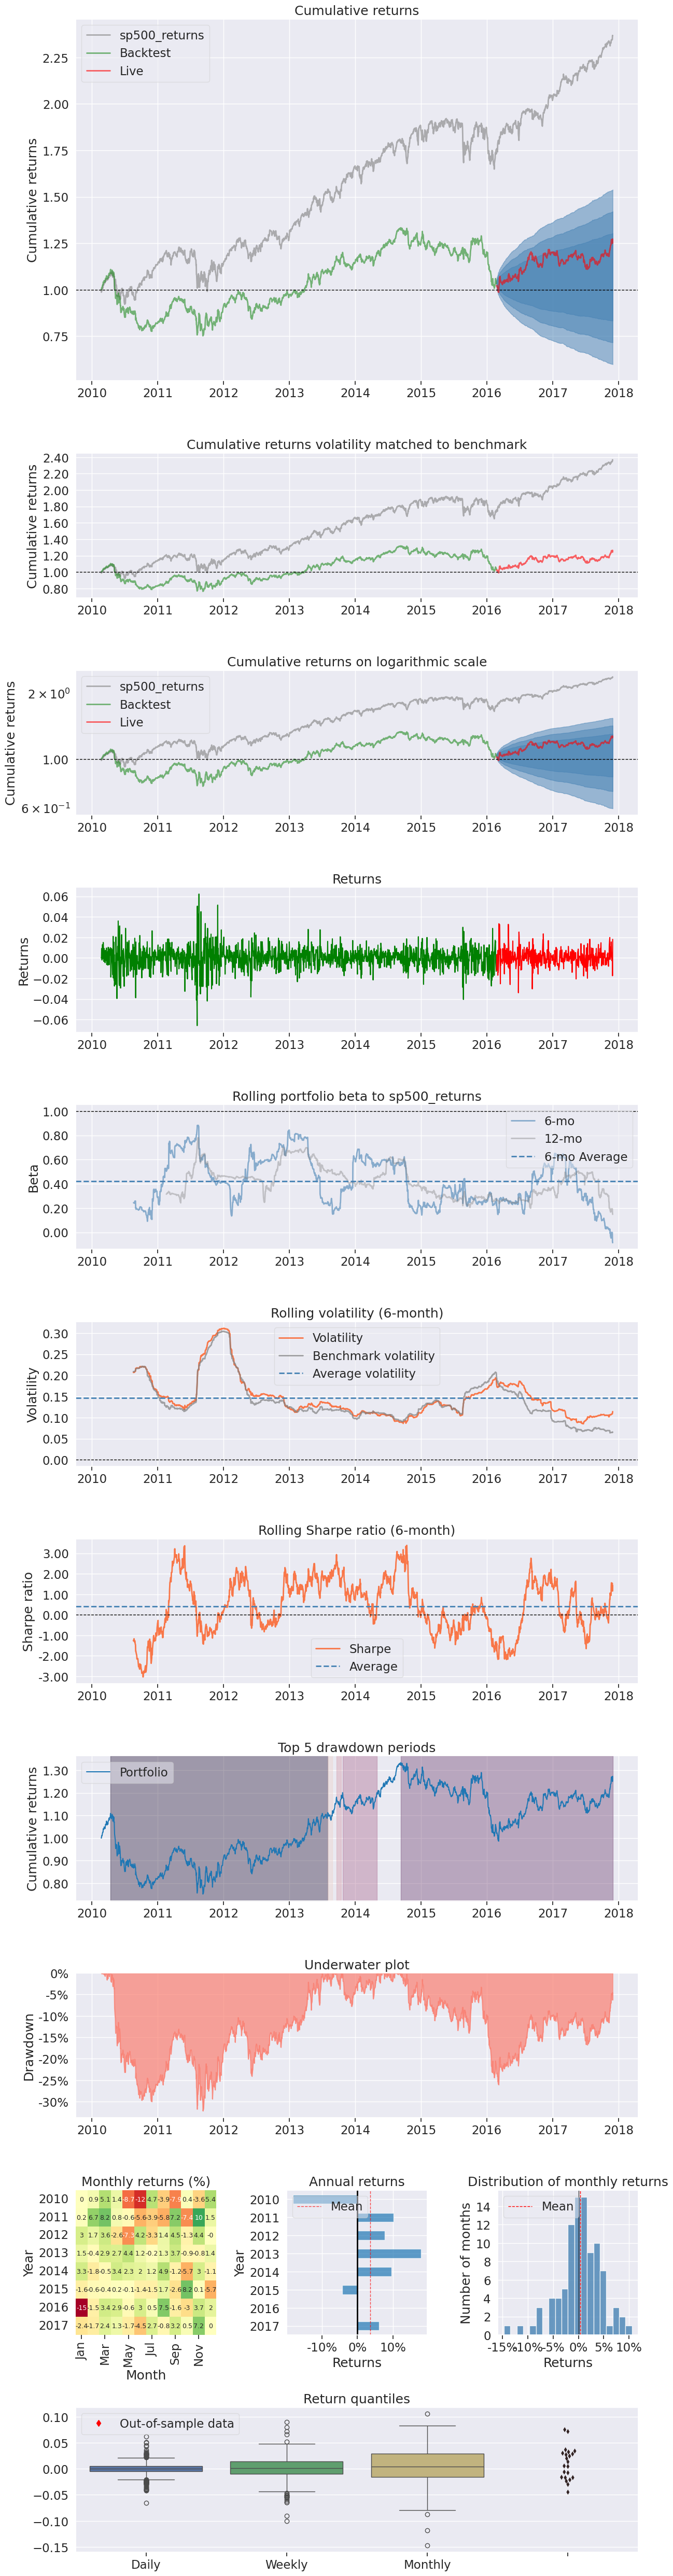

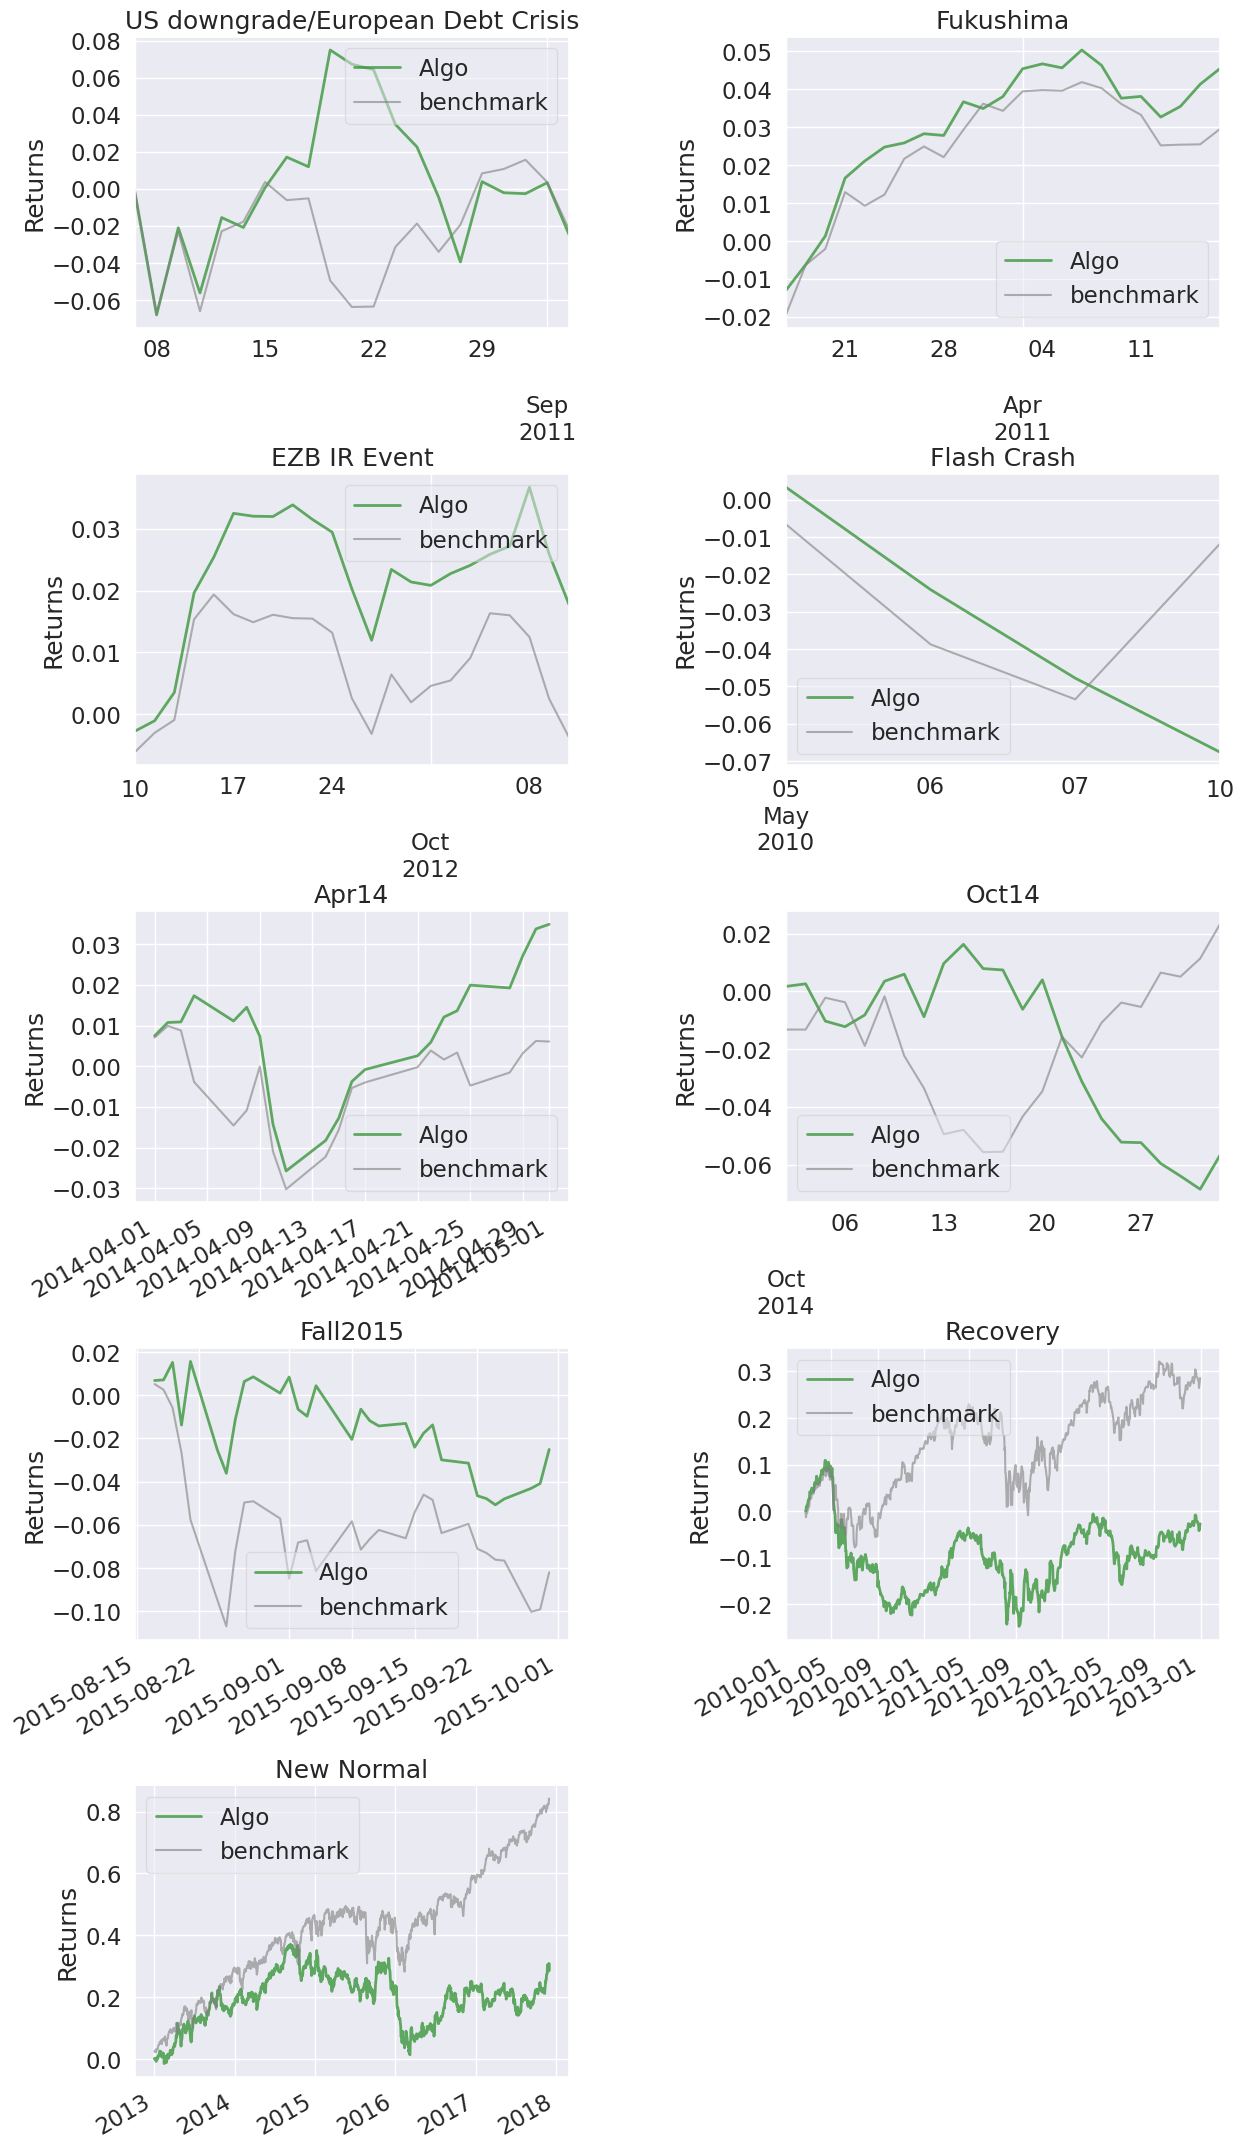

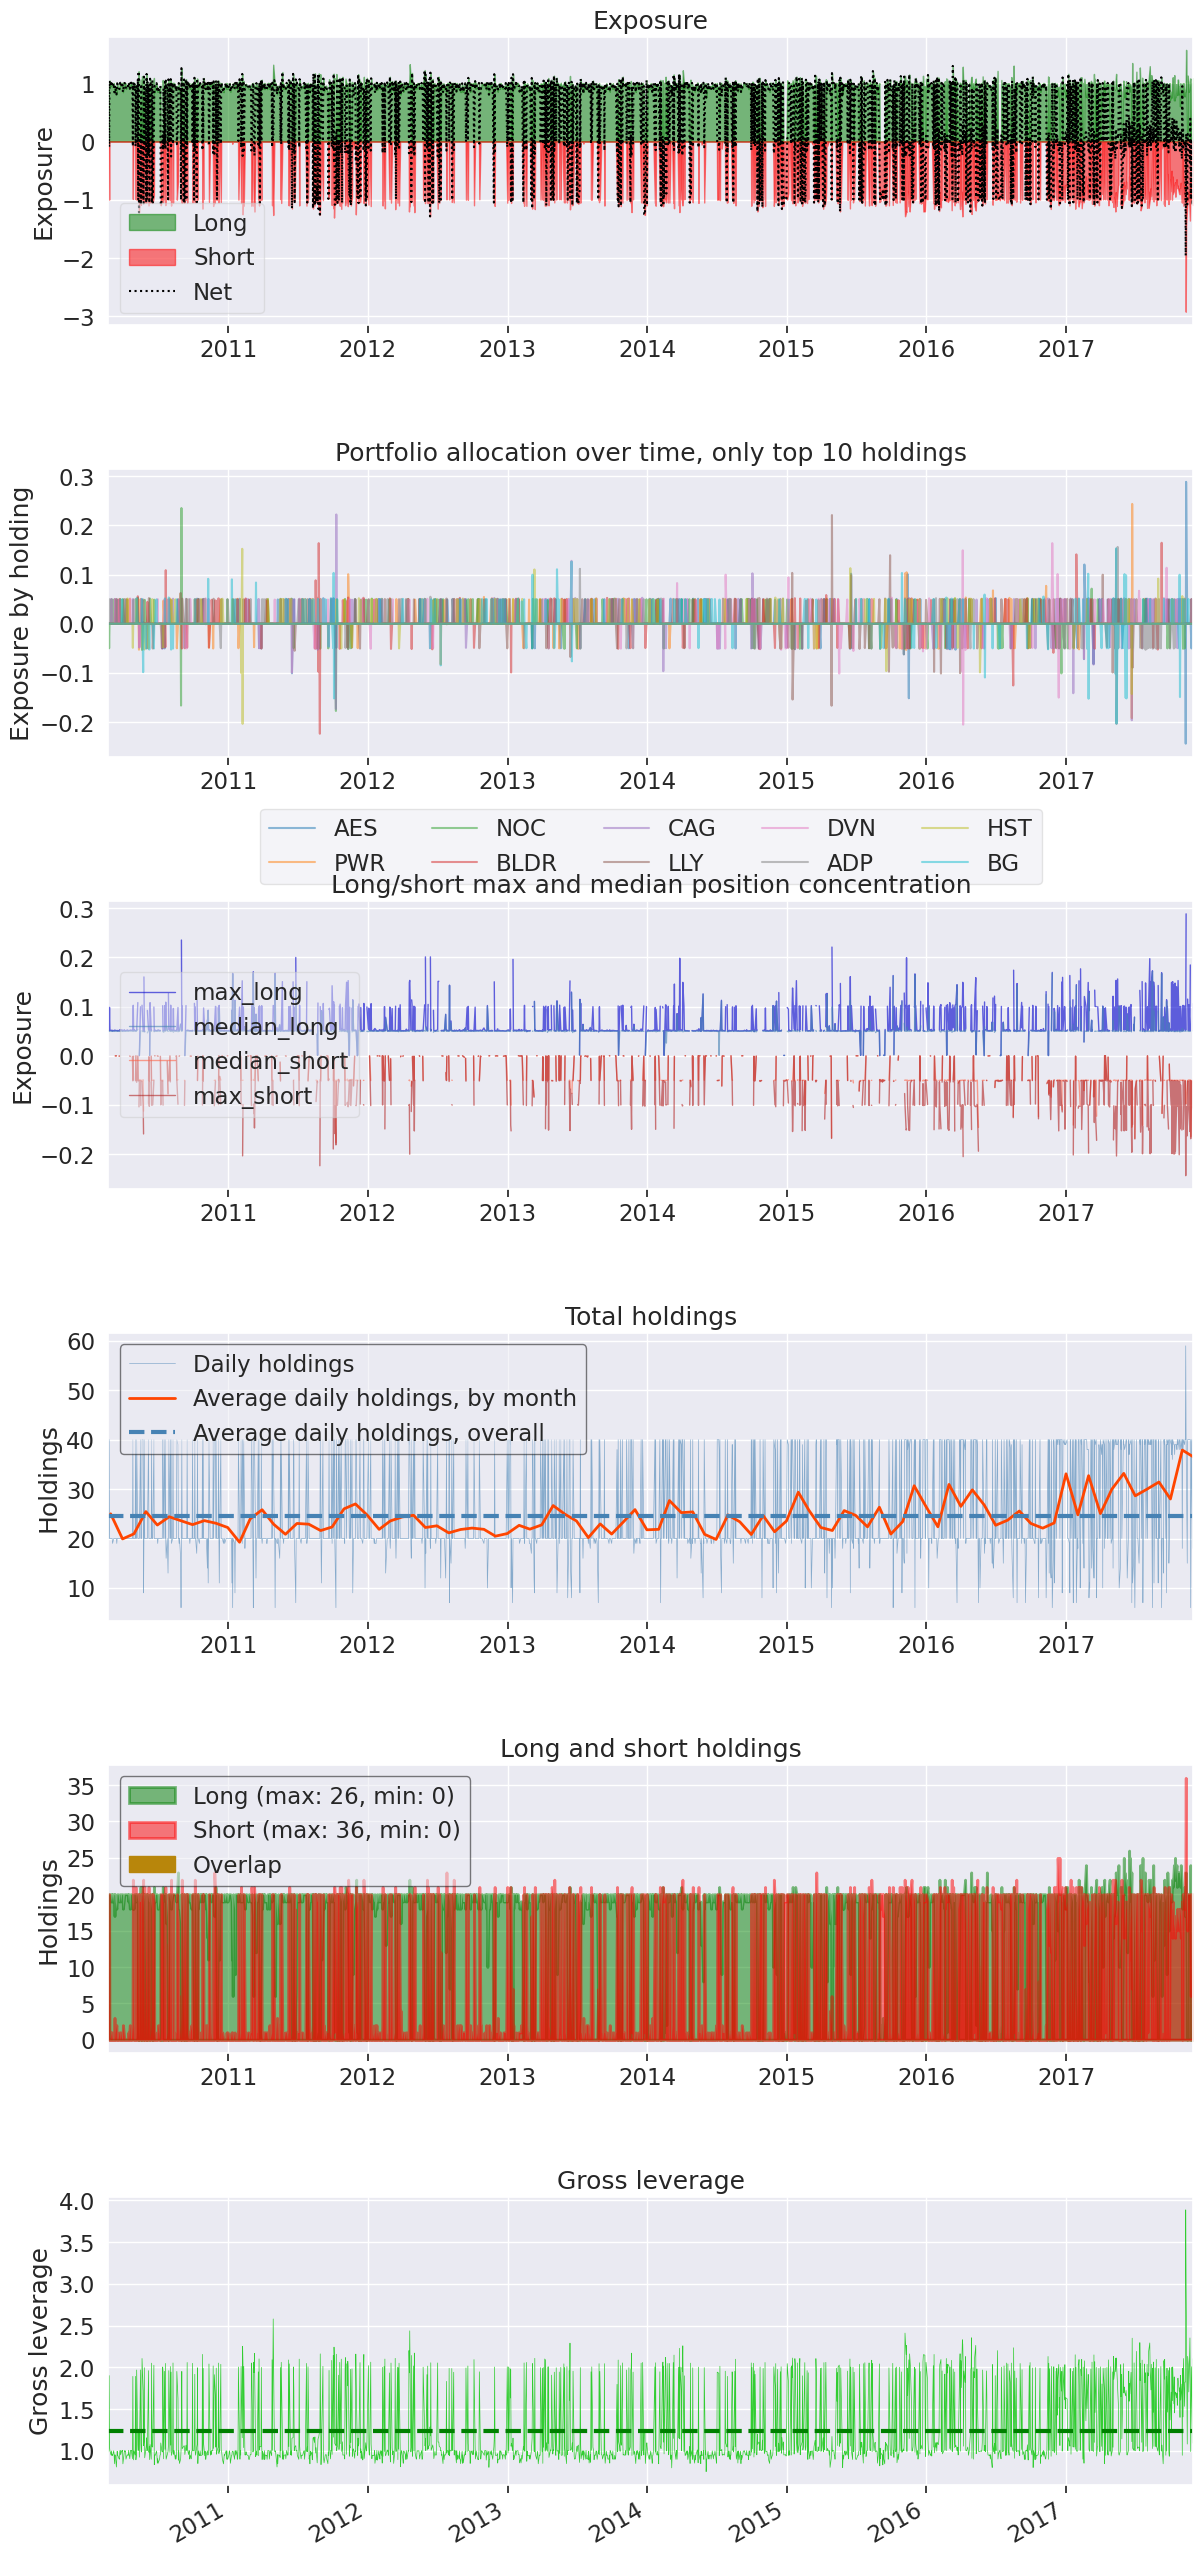

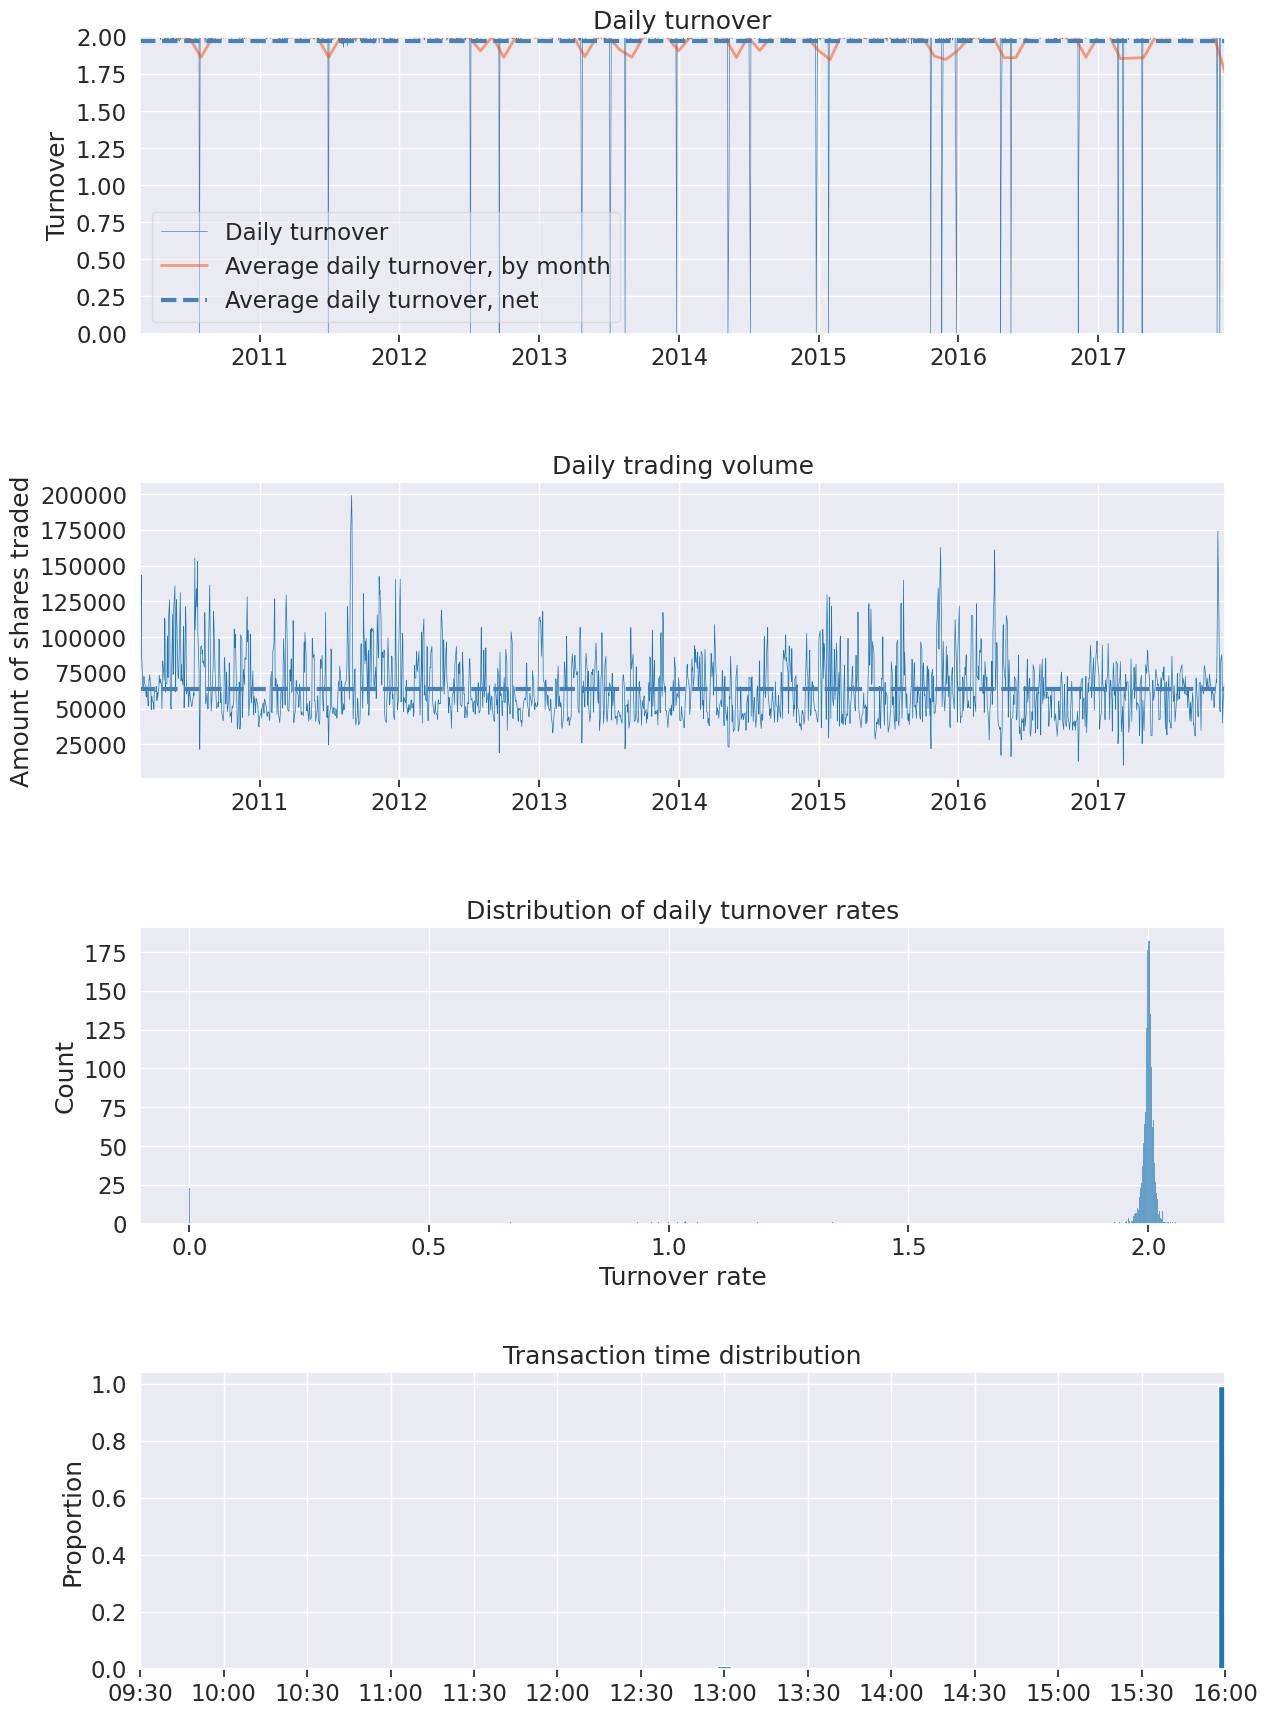

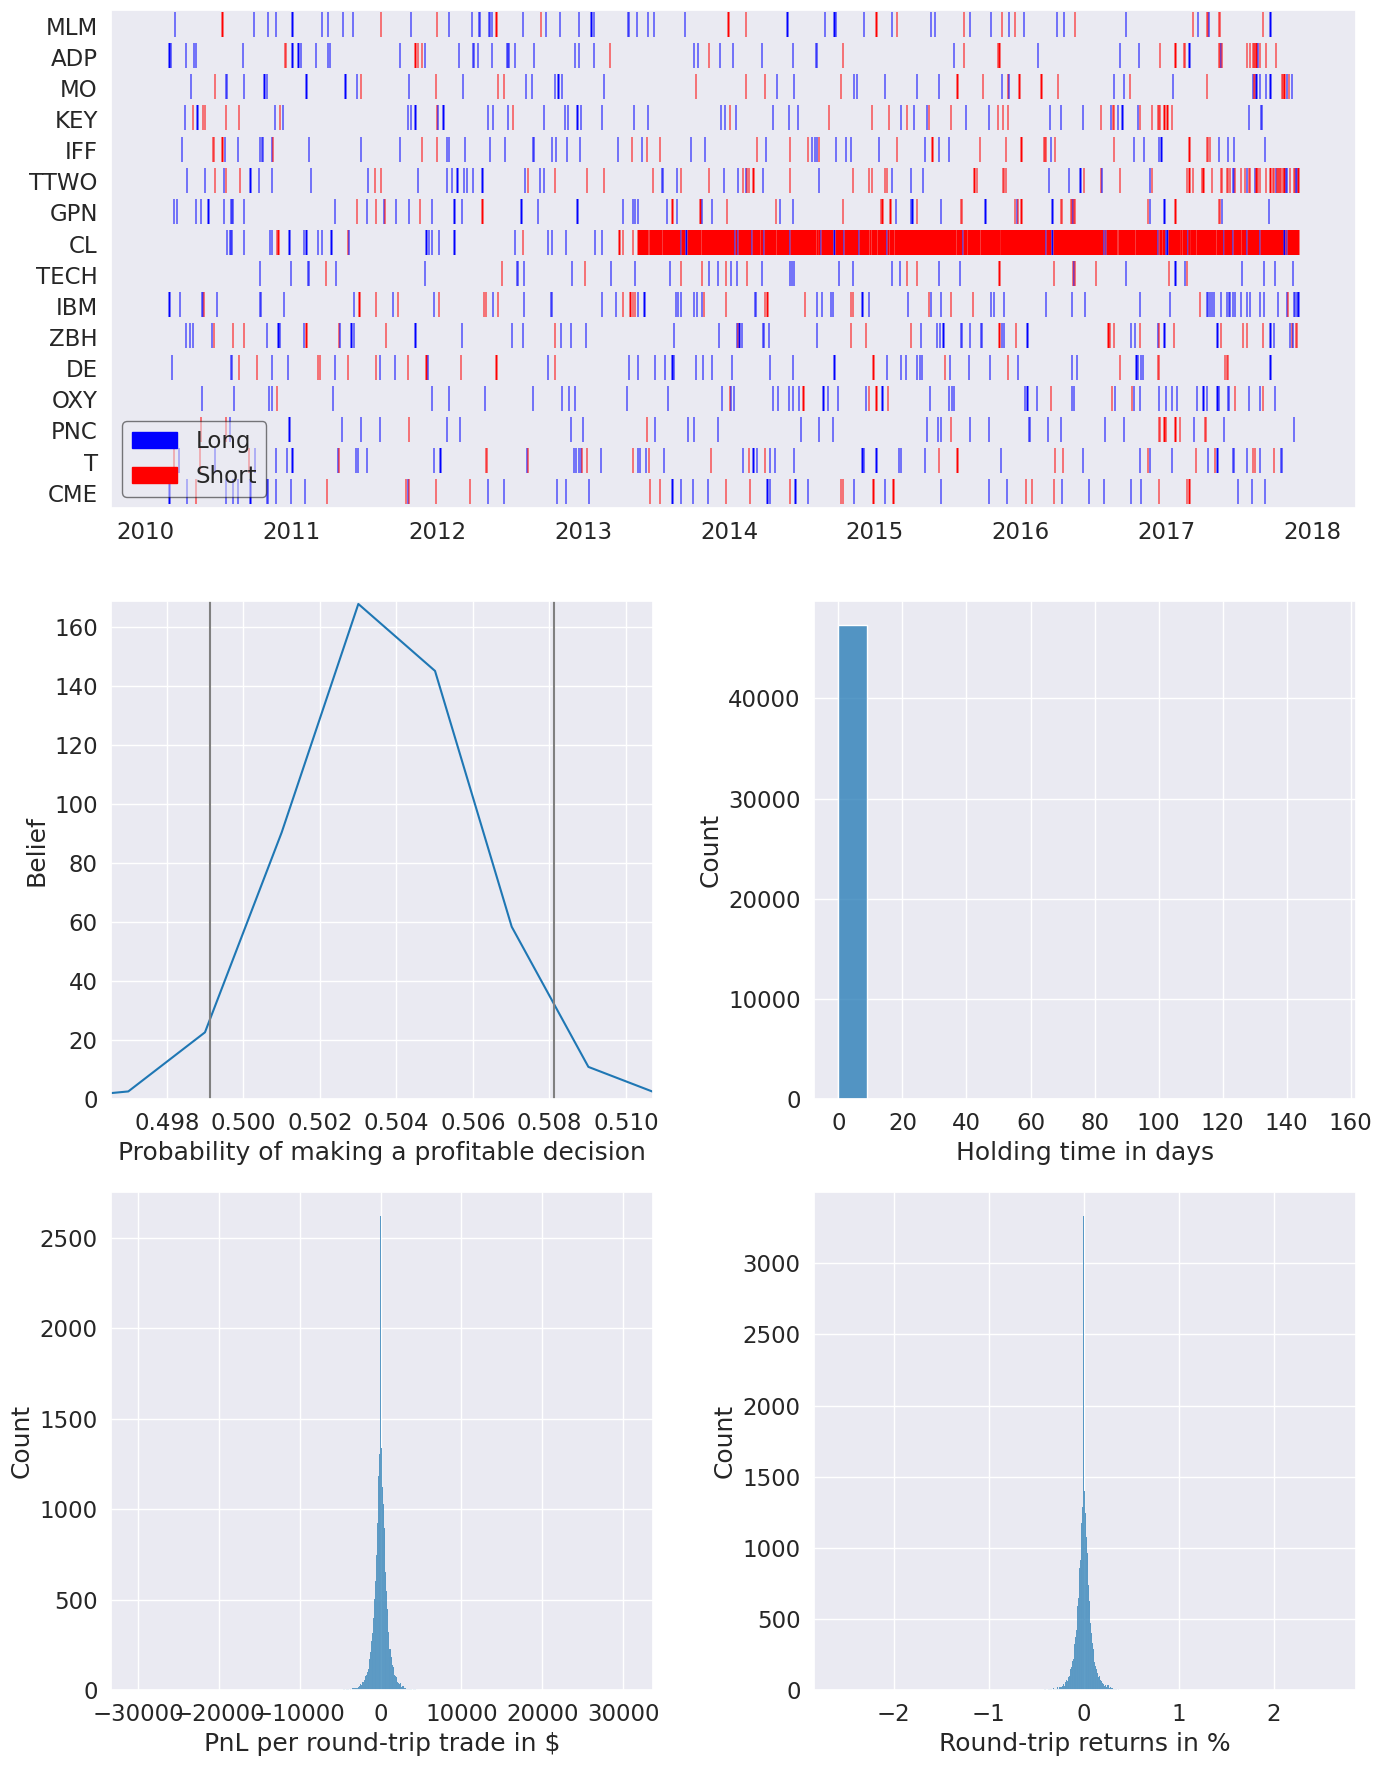

In [23]:
pf.create_full_tear_sheet(
    returns,
    positions=positions,
    transactions=transactions,
    benchmark_rets=benchmark_data,
    live_start_date=LIVE_DATE,
    round_trips=True
)